DALY CHALLENGE

Analyse des accidents d'avion et des décès jusqu'en 2023
1. Objectif

L'objectif de cette étude est d'analyser le jeu de données "Airplane Crashes and Fatalities Till 2023" afin d'identifier les tendances des accidents aériens, d'étudier les décès et les taux de survie, puis d'effectuer des analyses statistiques et des visualisations pertinentes.

2. Importation des bibliothèques

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

#Chargement du jeu de données

In [ ]:
df = pd.read_csv(
    "Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv",
    encoding="latin1"
)

df.head()

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


#Exploration initiale

In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(4998, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4998 non-null   object 
 1   Time                   3486 non-null   object 
 2   Location               4994 non-null   object 
 3   Operator               4988 non-null   object 
 4   Flight #               1329 non-null   object 
 5   Route                  4221 non-null   object 
 6   AC Type                4983 non-null   object 
 7   Registration           4724 non-null   object 
 8   cn/ln                  4330 non-null   object 
 9   Aboard                 4980 non-null   float64
 10  Aboard Passangers      4769 non-null   float64
 11  Aboard Crew            4772 non-null   float64
 12  Fatalities             4990 non-null   float64
 13  Fatalities Passangers  4756 non-null   float64
 14  Fatalities Crew        4757 non-null   float6

#Vérification des données



In [ ]:
df.describe()

,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground
count,4980.000000,4769.000000,4772.000000,4990.000000,4756.000000,4757.000000,4956.000000
mean,31.195984,27.009017,4.479254,22.373547,19.053827,3.578516,1.719128
std,45.534788,44.111609,3.483859,35.061741,34.146127,3.167922,55.540273
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,3.000000,2.000000,4.000000,1.000000,2.000000,0.000000
50%,16.000000,12.000000,4.000000,11.000000,8.000000,3.000000,0.000000
75%,35.000000,30.000000,6.000000,25.000000,21.000000,5.000000,0.000000
max,644.000000,614.000000,61.000000,583.000000,560.000000,46.000000,2750.000000


#Nettoyage des données
Conversion de la date

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

#Gestion des valeurs manquantes

In [ ]:
df["Fatalities"] = df["Fatalities"].fillna(0)
df["Aboard"] = df["Aboard"].fillna(0)

#Création de nouvelles variables

In [ ]:
df["Survivors"] = df["Aboard"] - df["Fatalities"]

df["Survival_Rate"] = np.where(
    df["Aboard"] > 0,
    (df["Survivors"] / df["Aboard"]) * 100,
    np.nan
)

df.head()

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,...,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary,Year,Month,Survivors,Survival_Rate
0,1908-09-17,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,...,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly...",1908,9,1.0,50.0
1,1909-09-07,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,...,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...,1909,9,0.0,0.0
2,1912-07-12,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,...,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,1912,7,0.0,0.0
3,1913-08-06,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,...,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...,1913,8,0.0,0.0
4,1913-09-09,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,...,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...,1913,9,6.0,30.0


#Analyse exploratoire des données (EDA)
Nombre total d'accidents

In [ ]:
total_accidents = len(df)

print("Nombre total d'accidents :", total_accidents)

Nombre total d'accidents : 4998


Nombre total de décès

In [ ]:
total_fatalities = df["Fatalities"].sum()

print("Nombre total de décès :", total_fatalities)

Nombre total de décès : 111644.0


#Taux moyen de survie

In [ ]:
print(df["Survival_Rate"].mean())

18.1489019431307


#Accidents par année

In [ ]:
accidents_per_year = df.groupby("Year").size()

accidents_per_year.head()

,0
Year,
1908,1
1909,1
1912,1
1913,3
1915,2


# Analyse statistique avec SciPy
Statistiques descriptives des décès

In [ ]:
mean_fatalities = np.mean(df["Fatalities"])

median_fatalities = np.median(df["Fatalities"])

std_fatalities = np.std(df["Fatalities"])

print("Moyenne :", mean_fatalities)
print("Médiane :", median_fatalities)
print("Écart-type :", std_fatalities)

Moyenne : 22.337735094037615
Médiane : 11.0
Écart-type : 35.04157452812883


Interprétation
En moyenne, chaque accident provoque environ 22 décès.
La médiane est de 11 décès.
L'écart-type élevé montre une forte dispersion des données.

#Test d'hypothèse

Comparaison des décès avant et après 1980.

In [ ]:
df["Decade"] = (df["Year"] // 10) * 10

group1 = df[df["Decade"] < 1980]["Fatalities"]

group2 = df[df["Decade"] >= 1980]["Fatalities"]

t_stat, p_value = stats.ttest_ind(
    group1,
    group2,
    equal_var=False
)

print("Statistique t :", t_stat)
print("P-value :", p_value)

Statistique t : -5.787008818348186
P-value : 7.919559634623138e-09


Interprétation

La valeur p est inférieure à 0,05.

On rejette donc l'hypothèse nulle.

Il existe une différence statistiquement significative entre le nombre moyen de décès avant et après 1980.

Visualisations
Évolution du nombre d'accidents

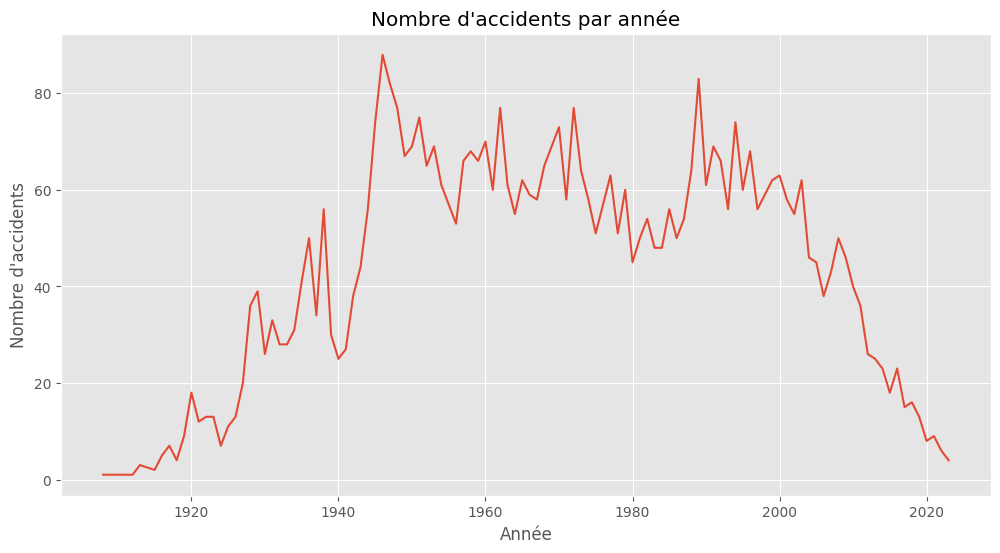

In [ ]:
plt.figure(figsize=(12,6))

accidents_per_year.plot()

plt.title("Nombre d'accidents par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'accidents")

plt.show()

Histogramme des décès

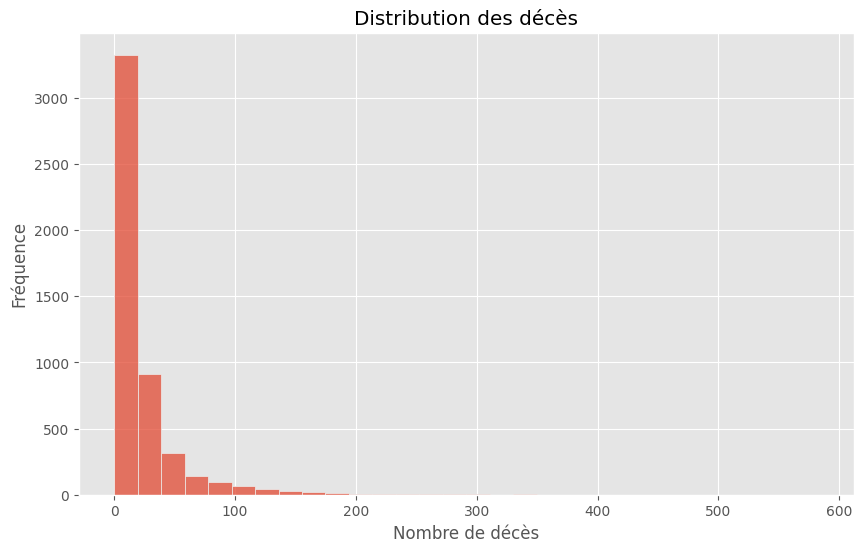

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df["Fatalities"], bins=30)

plt.title("Distribution des décès")
plt.xlabel("Nombre de décès")
plt.ylabel("Fréquence")

plt.show()

Boîte à moustaches des décès

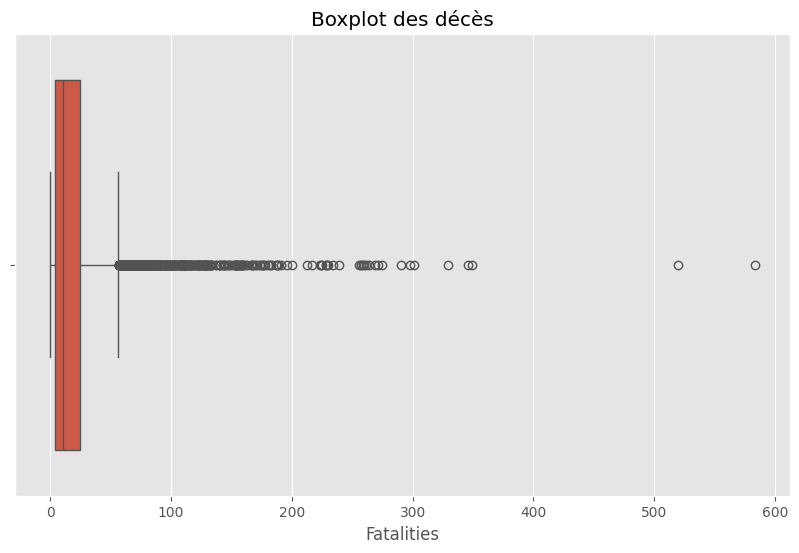

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(x=df["Fatalities"])

plt.title("Boxplot des décès")

plt.show()

Décès moyens par décennie

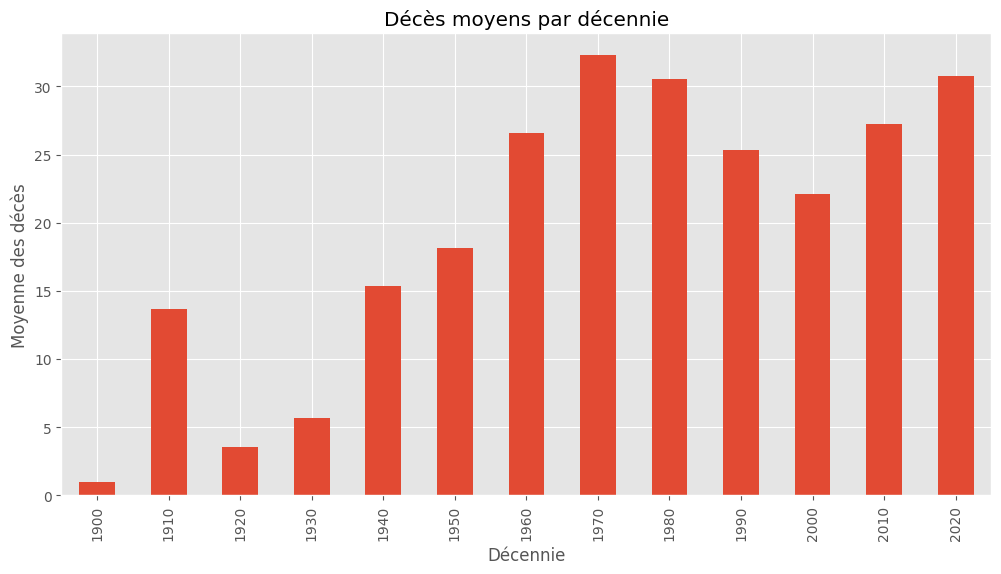

In [ ]:
fatalities_decade = df.groupby("Decade")["Fatalities"].mean()

plt.figure(figsize=(12,6))

fatalities_decade.plot(kind="bar")

plt.title("Décès moyens par décennie")
plt.xlabel("Décennie")
plt.ylabel("Moyenne des décès")

plt.show()

Taux de survie

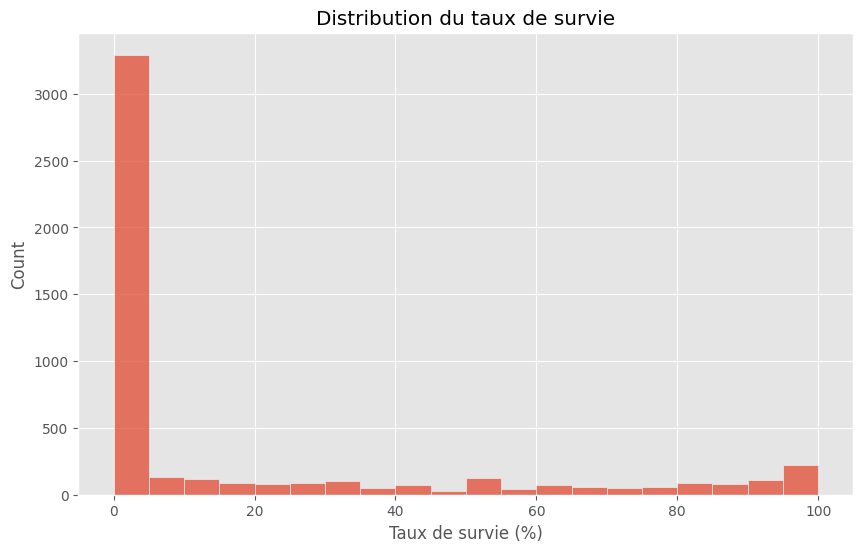

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df["Survival_Rate"], bins=20)

plt.title("Distribution du taux de survie")
plt.xlabel("Taux de survie (%)")

plt.show()

9. Conclusions

L'analyse du jeu de données a révélé plusieurs observations importantes :

Le jeu de données contient 4 998 accidents aériens enregistrés entre 1908 et 2023.
Le nombre total de décès est de 111 644 personnes.
Le nombre moyen de décès par accident est de 22,37 personnes.
La médiane de 11 décès indique que certains accidents extrêmement meurtriers influencent fortement la moyenne.
L'analyse temporelle montre une évolution du nombre d'accidents selon les périodes historiques.
Le test statistique effectué avec SciPy démontre une différence significative entre les décès enregistrés avant et après 1980.
Les visualisations mettent en évidence une forte variabilité du nombre de victimes ainsi que des différences notables entre les décennies.



# 10. Utilisation des bibliothèques

### Pandas

* Chargement des données
* Nettoyage des données
* Manipulation des colonnes
* Calcul des statistiques descriptives

### NumPy

* Calcul de la moyenne
* Calcul de la médiane
* Calcul de l'écart-type
* Création des variables dérivées

### SciPy

* Réalisation du test d'hypothèse (test t)

### Matplotlib et Seaborn

* Création des graphiques
* Histogrammes
* Courbes temporelles
* Diagrammes en barres
* Boxplots